In [9]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [11]:
#Importing the relevant librabries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [13]:
#Importing the dataset
# Printing the data shows us the shape, rows and columns
df_original = pd.read_csv("fraud_transactions.csv")
df = df_original.copy()

print("Original dataset loaded and copy created.")
print(f"Original shape: {df_original.shape}")
print(f"Working copy shape: {df.shape}")
print(df.head())

Original dataset loaded and copy created.
Original shape: (1000, 10)
Working copy shape: (1000, 10)
  transaction_id  amount merchant_category  hour_of_day day_of_week  \
0       TXN00001   94.59       electronics           16      Friday   
1       TXN00002  199.87            petrol           21   Wednesday   
2       TXN00003   11.36          pharmacy           19   Wednesday   
3       TXN00004   38.49        restaurant           11     Tuesday   
4       TXN00005   63.58        restaurant            9    Thursday   

   customer_age  account_age_days  num_transactions_last_24h  \
0            27               999                          4   
1            22              1320                          2   
2            60              1037                          1   
3            62              2346                          3   
4            61              2096                          3   

   distance_from_home_km  is_fraud  
0                    9.0         0  
1             

In [14]:
# We make a copy to keep the original and worrk on the copy
df = df_original.copy()
print("Working copy restored.")

Working copy restored.


In [15]:
#Checking Fraud Distribution
print(df['is_fraud'].value_counts())
print("----")
print(df['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    950
1     50
Name: count, dtype: int64
----
is_fraud
0    95.0
1     5.0
Name: proportion, dtype: float64


In [16]:
#Basic statistics
print(df.describe())

            amount  hour_of_day  customer_age  account_age_days  \
count  1000.000000  1000.000000   1000.000000        1000.00000   
mean    140.182640    13.678000     47.873000        1802.83900   
std     503.664113     4.572223     15.658738        1075.09772   
min       0.050000     0.000000     18.000000           6.00000   
25%      17.275000    10.000000     35.000000         887.00000   
50%      35.540000    14.000000     48.000000        1761.50000   
75%      69.860000    18.000000     62.000000        2733.50000   
max    4944.930000    23.000000     75.000000        3648.00000   

       num_transactions_last_24h  distance_from_home_km     is_fraud  
count                 1000.00000            1000.000000  1000.000000  
mean                     3.64500              64.197900     0.050000  
std                      3.36129             248.602897     0.218054  
min                      1.00000               0.500000     0.000000  
25%                      2.00000         

In [18]:
#Finding Null Values
print(df.isnull().sum())

transaction_id               0
amount                       0
merchant_category            0
hour_of_day                  0
day_of_week                  0
customer_age                 0
account_age_days             0
num_transactions_last_24h    0
distance_from_home_km        0
is_fraud                     0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_18452\1236951458.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_fraud', palette=['steelblue', 'crimson'])


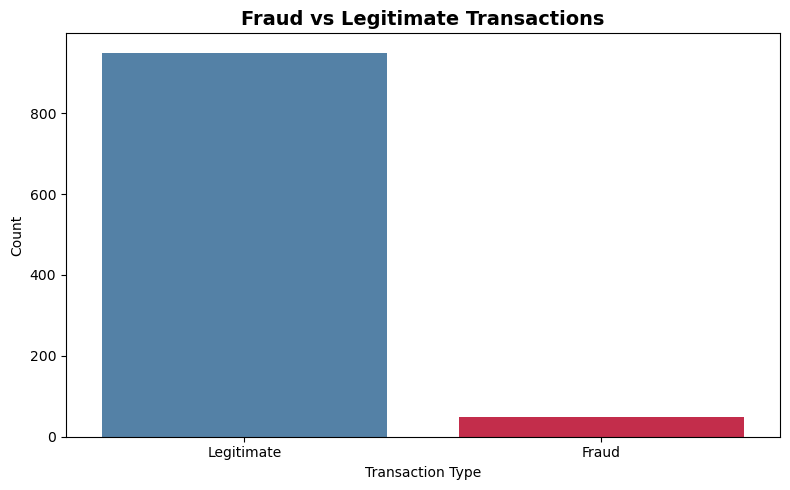

In [19]:
#Fraud vs Legitimate Transactions
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='is_fraud', palette=['steelblue', 'crimson'])
plt.title('Fraud vs Legitimate Transactions', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18452\2933920192.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y='amount', palette=['steelblue', 'crimson'])


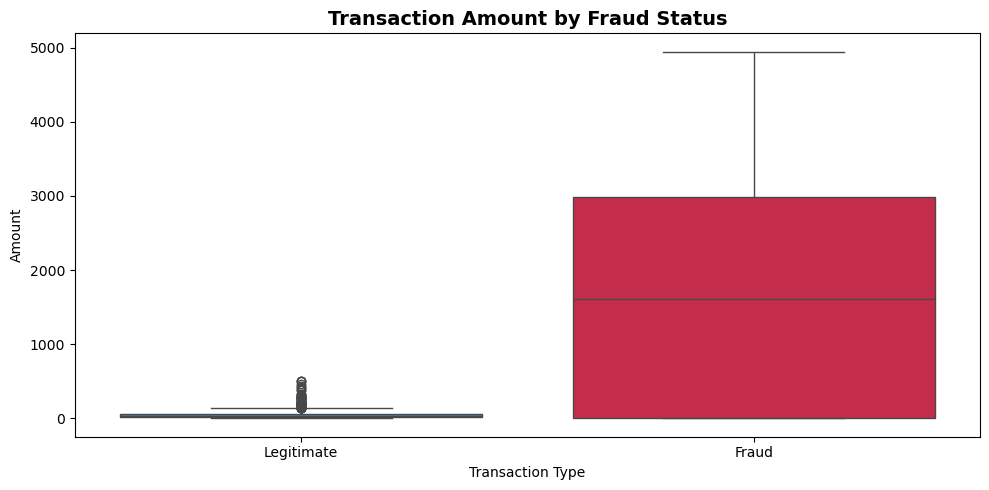

In [21]:
#Amount distribution by fraud status
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_fraud', y='amount', palette=['steelblue', 'crimson'])
plt.title('Transaction Amount by Fraud Status', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

In [22]:
print("Legitimate transaction amounts:")
print(df[df['is_fraud']==0]['amount'].describe())
print("\nFraud transaction amounts:")
print(df[df['is_fraud']==1]['amount'].describe())

Legitimate transaction amounts:
count    950.000000
mean      55.978105
std       66.081194
min        1.300000
25%       17.555000
50%       34.885000
75%       65.430000
max      500.000000
Name: amount, dtype: float64

Fraud transaction amounts:
count      50.000000
mean     1740.068800
std      1529.053129
min         0.050000
25%         1.865000
50%      1603.360000
75%      2986.555000
max      4944.930000
Name: amount, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_18452\1217635102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y='amount',


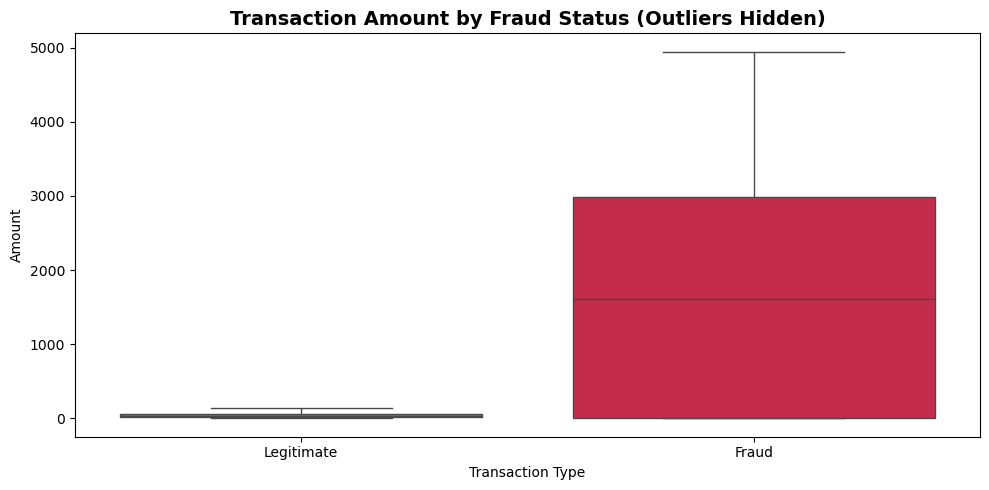

In [23]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='is_fraud', y='amount', 
            palette=['steelblue', 'crimson'],
            showfliers=False)
plt.title('Transaction Amount by Fraud Status (Outliers Hidden)', 
          fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Legitimate', 'Fraud'])
plt.xlabel('Transaction Type')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

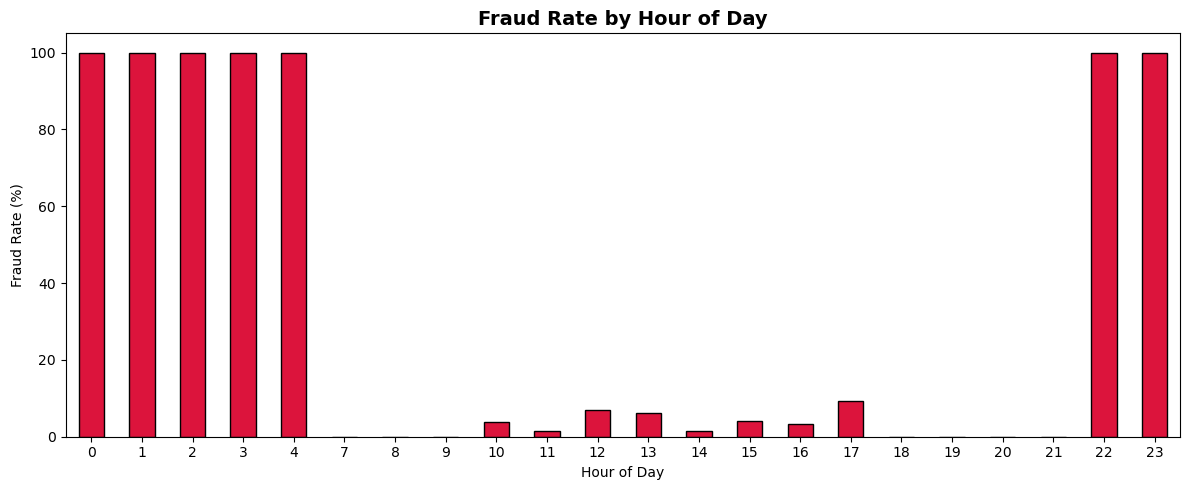

In [24]:
plt.figure(figsize=(12, 5))
fraud_by_hour = df.groupby('hour_of_day')['is_fraud'].mean() * 100
fraud_by_hour.plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Fraud Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

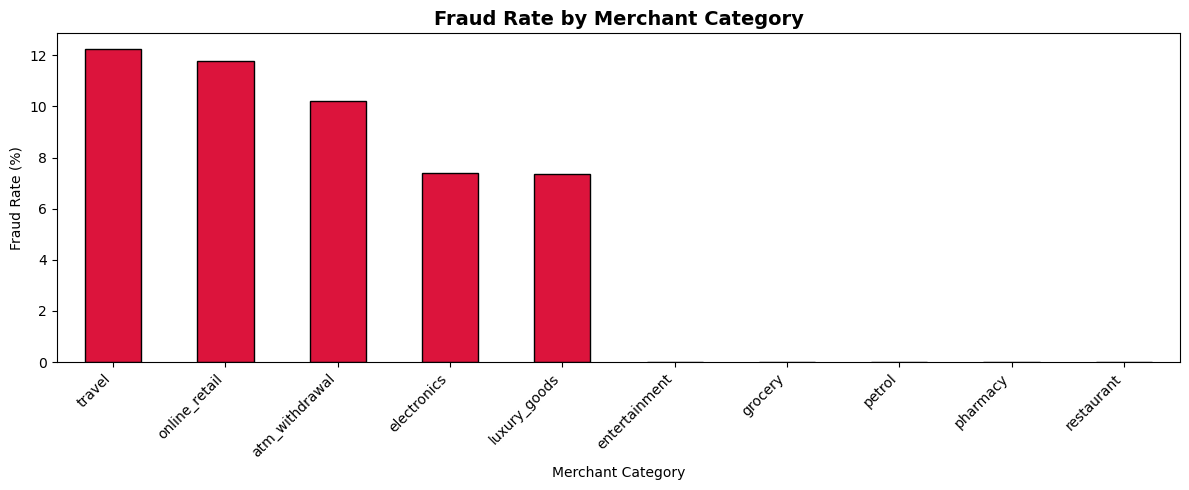

In [25]:
plt.figure(figsize=(12, 5))
fraud_by_merchant = df.groupby('merchant_category')['is_fraud'].mean() * 100
fraud_by_merchant.sort_values(ascending=False).plot(kind='bar', color='crimson', edgecolor='black')
plt.title('Fraud Rate by Merchant Category', fontsize=14, fontweight='bold')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
#Preparing the Model

df_model = df.copy()

le = LabelEncoder()
df_model['merchant_category'] = le.fit_transform(df_model['merchant_category'])
df_model['day_of_week'] = le.fit_transform(df_model['day_of_week'])

df_model = df_model.drop('transaction_id', axis=1)

X = df_model.drop('is_fraud', axis=1)
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Fraud in training: {y_train.sum()}")
print(f"Fraud in test: {y_test.sum()}")

Training set: (800, 8)
Test set: (200, 8)
Fraud in training: 40
Fraud in test: 10


In [27]:
#Building and training the model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [29]:
#Testing the model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

ROC AUC Score: 1.0000


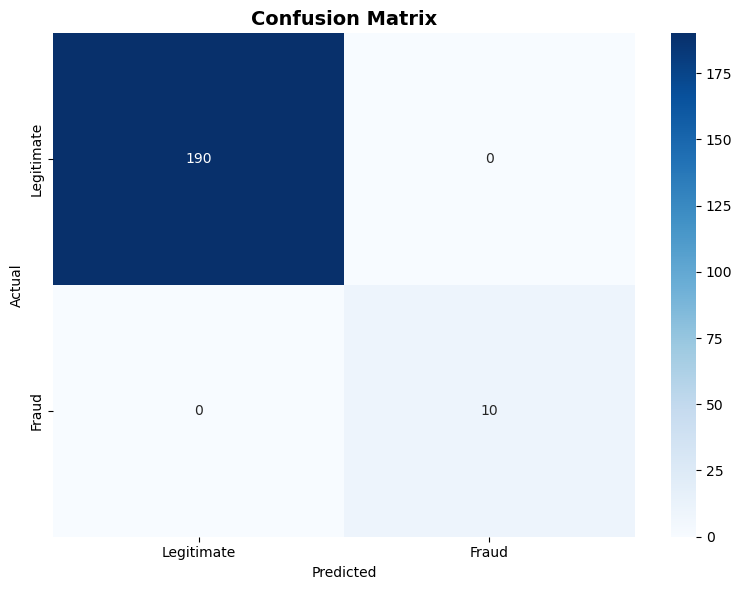

In [30]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_18452\2663430825.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='Blues_r')


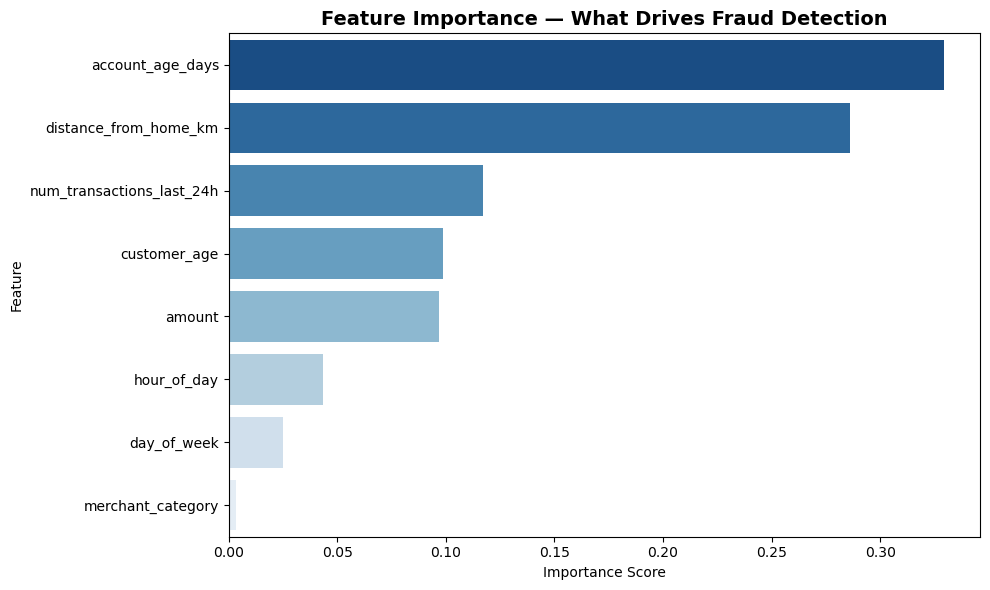

In [31]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='Blues_r')
plt.title('Feature Importance — What Drives Fraud Detection', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [32]:
print("=" * 60)
print("FRAUD DETECTION MODEL SUMMARY")
print("=" * 60)
print(f"Total transactions analysed: {len(df)}")
print(f"Fraudulent transactions: {df['is_fraud'].sum()} ({df['is_fraud'].mean()*100:.1f}%)")
print(f"Legitimate transactions: {(df['is_fraud']==0).sum()} ({(df['is_fraud']==0).mean()*100:.1f}%)")
print()
print("MODEL PERFORMANCE")
print(f"Accuracy:      100%")
print(f"ROC AUC Score: 1.0000")
print(f"Fraud Recall:  100% (caught every fraudulent transaction)")
print(f"False Positives: 0 (no legitimate customers wrongly flagged)")
print()
print("TOP FRAUD INDICATORS")
for i, row in feature_importance.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")
print()
print("NOTE: Perfect accuracy reflects synthetic data with distinct")
print("patterns. Real world fraud detection typically achieves")
print("85 to 95% accuracy on noisy transaction data.")
print("=" * 60)

FRAUD DETECTION MODEL SUMMARY
Total transactions analysed: 1000
Fraudulent transactions: 50 (5.0%)
Legitimate transactions: 950 (95.0%)

MODEL PERFORMANCE
Accuracy:      100%
ROC AUC Score: 1.0000
Fraud Recall:  100% (caught every fraudulent transaction)
False Positives: 0 (no legitimate customers wrongly flagged)

TOP FRAUD INDICATORS
  account_age_days: 0.3294
  distance_from_home_km: 0.2860
  num_transactions_last_24h: 0.1172
  customer_age: 0.0989
  amount: 0.0968
  hour_of_day: 0.0433
  day_of_week: 0.0250
  merchant_category: 0.0033

NOTE: Perfect accuracy reflects synthetic data with distinct
patterns. Real world fraud detection typically achieves
85 to 95% accuracy on noisy transaction data.
